In [ ]:
# Here I am putting the SYSTEM SETUP CELL — run once purpose

# Install Stockfish engine
!apt-get -qq update
!apt-get -qq install -y stockfish

# Install Python libraries
!pip -q install python-chess scikit-learn tensorflow opencv-python mysql-connector-python selenium


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package stockfish.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../stockfish_14.1-1_amd64.deb ...
Unpacking stockfish (14.1-1) ...
Setting up stockfish (14.1-1) ...
Processing triggers for man-db (2.10.2-1) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 48.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.0/512.0 kB 35.3 MB/s eta 0:00:00


In [ ]:
# Test Stockfish installation and basic move evaluation

import chess
import chess.engine

engine_path = "/usr/games/stockfish"

engine = chess.engine.SimpleEngine.popen_uci(engine_path)

board = chess.Board()

# Testing the engine by asking for best move from starting position
result = engine.play(board, chess.engine.Limit(time=0.1))

print("Hey boy! I am Stockfish & I am working!")
print("Best move from starting position:", result.move)

engine.quit()


Hey boy! I am Stockfish & I am working!
Best move from starting position: e2e4


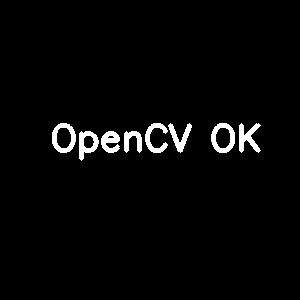

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Create a dummy image to verify OpenCV works
img = np.zeros((300, 300, 3), dtype=np.uint8)
cv2.putText(img, "OpenCV OK", (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,255,255), 3)

cv2_imshow(img)

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Screenshot 2025-12-06 143825.png to Screenshot 2025-12-06 143825.png


Board detected!


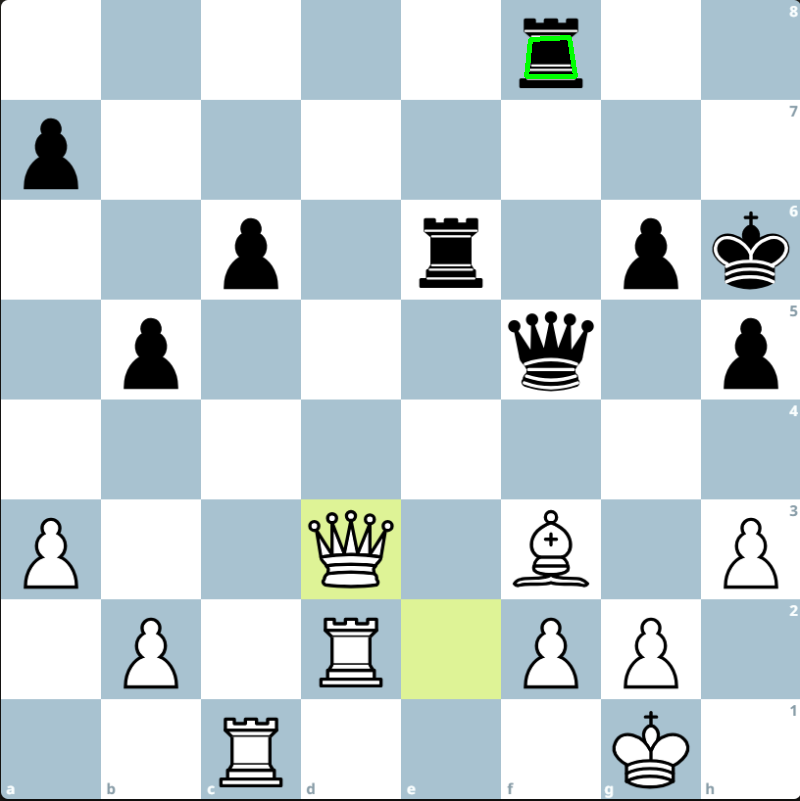

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

filename = "Screenshot 2025-12-06 143825.png"

# Load image
img = cv2.imread(filename)
orig = img.copy()

# Resize to manageable size
img = cv2.resize(img, (800, int(img.shape[0] * 800 / img.shape[1])))

# Preprocess
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)

# Find contours
cnts, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

biggest = None
max_area = 0

for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)

    if len(approx) == 4:
        area = cv2.contourArea(approx)
        if area > max_area:
            biggest = approx
            max_area = area

# Draw detected contour
detected = img.copy()
if biggest is not None:
    cv2.drawContours(detected, [biggest], -1, (0,255,0), 3)
    print("Board detected!")
else:
    print("Board NOT detected!")

cv2_imshow(detected)

Could not detect full board.


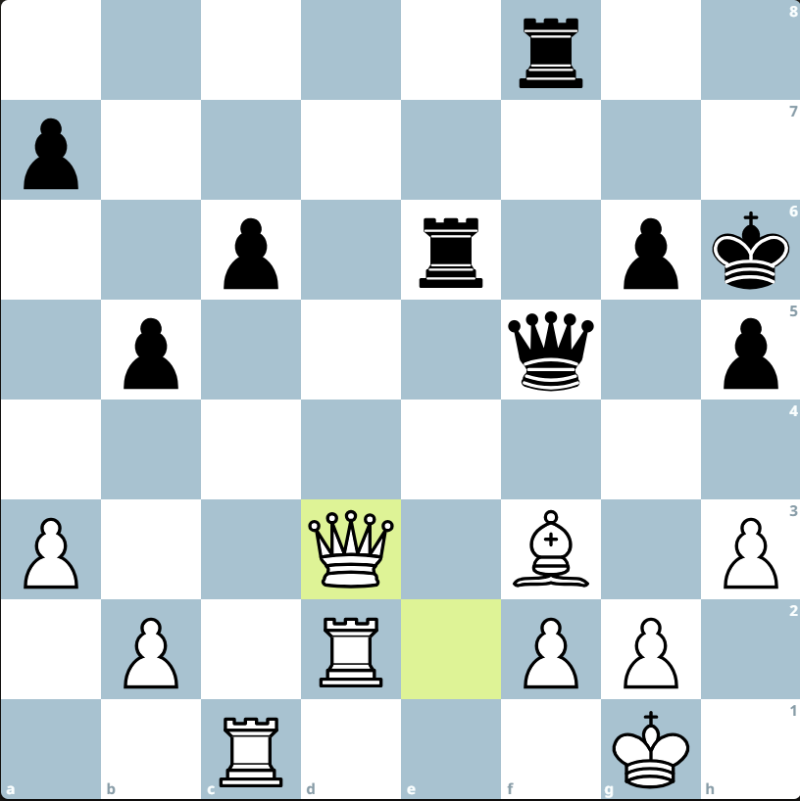

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

filename = "Screenshot 2025-12-06 143825.png"

img = cv2.imread(filename)
orig = img.copy()

img = cv2.resize(img, (800, int(img.shape[0] * 800 / img.shape[1])))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 30, 100)

cnts, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

biggest = None
max_area = 0

for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.015 * peri, True)

    if len(approx) == 4:
        area = cv2.contourArea(approx)

        # FILTER 1 — must be big enough
        if area < 50000:
            continue

        # FILTER 2 — shape must be nearly square
        x, y, w, h = cv2.boundingRect(approx)
        ratio = w / float(h)
        if ratio < 0.8 or ratio > 1.2:
            continue

        if area > max_area:
            biggest = approx
            max_area = area

detected = img.copy()
if biggest is not None:
    cv2.drawContours(detected, [biggest], -1, (0, 255, 0), 3)
    print("Correct board detected!")
else:
    print("Could not detect full board.")

cv2_imshow(detected)

Vertical lines: 8
Horizontal lines: 8


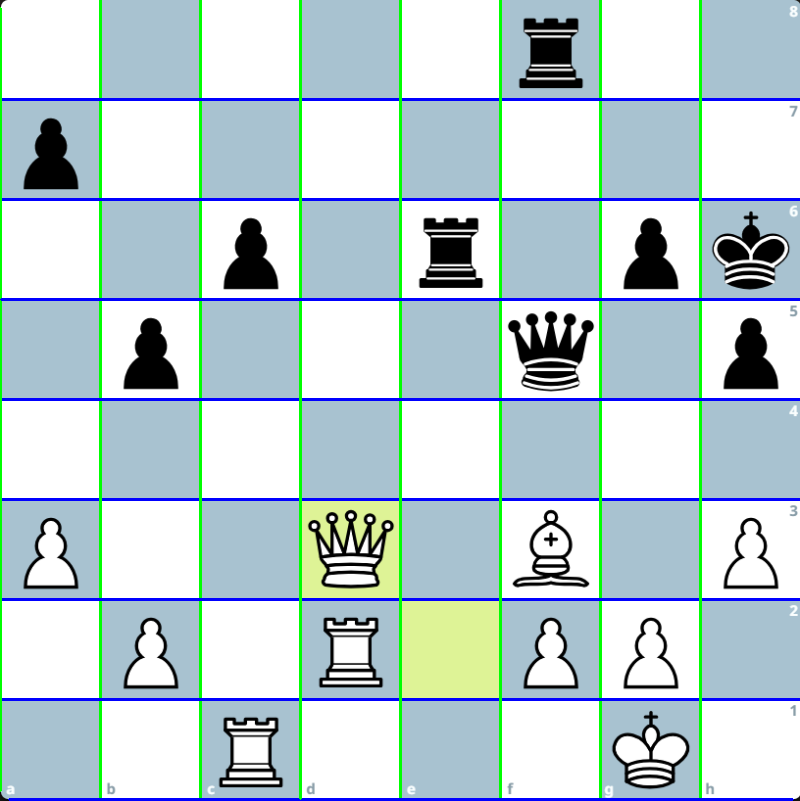

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

filename = "Screenshot 2025-12-06 143825.png"

# Load + resize
img = cv2.imread(filename)
img = cv2.resize(img, (800, int(img.shape[0] * 800 / img.shape[1])))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# Detect lines
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=200,
    maxLineGap=20
)

output = img.copy()

# Separate vertical + horizontal lines
vertical_lines = []
horizontal_lines = []

for line in lines:
    x1, y1, x2, y2 = line[0]
    if abs(x1 - x2) < 20:   # vertical
        vertical_lines.append((x1, y1, x2, y2))
        cv2.line(output, (x1, y1), (x2, y2), (0,255,0), 2)
    elif abs(y1 - y2) < 20: # horizontal
        horizontal_lines.append((x1, y1, x2, y2))
        cv2.line(output, (x1, y1), (x2, y2), (255,0,0), 2)

print("Vertical lines:", len(vertical_lines))
print("Horizontal lines:", len(horizontal_lines))

cv2_imshow(output)

Cell 1


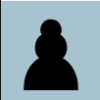

Cell 2


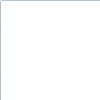

Cell 3


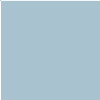

Cell 4


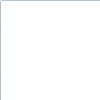

Cell 5


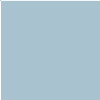

Cell 6


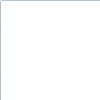

Cell 7


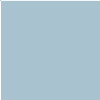

Cell 8


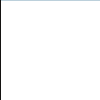

Cell 9


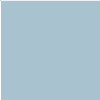

Cell 10


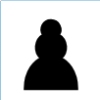

Cell 11


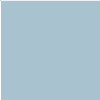

Cell 12


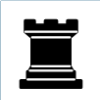

Cell 13


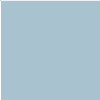

Cell 14


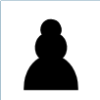

Cell 15


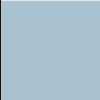

Cell 16


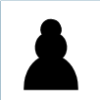

Cell 17


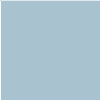

Cell 18


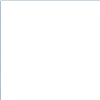

Cell 19


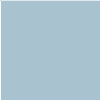

Cell 20


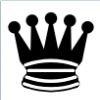

Cell 21


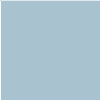

Cell 22


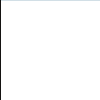

Cell 23


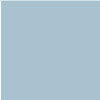

Cell 24


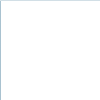

Cell 25


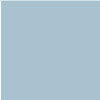

Cell 26


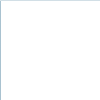

Cell 27


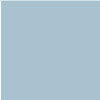

Cell 28


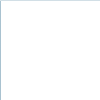

Cell 29


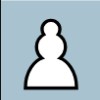

Cell 30


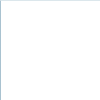

Cell 31


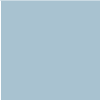

Cell 32


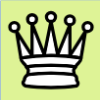

Cell 33


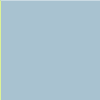

Cell 34


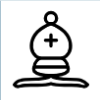

Cell 35


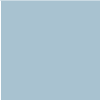

Cell 36


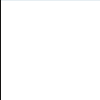

Cell 37


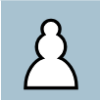

Cell 38


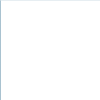

Cell 39


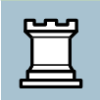

Cell 40


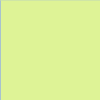

Cell 41


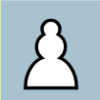

Cell 42


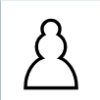

Cell 43


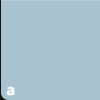

Cell 44


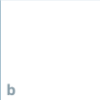

Cell 45


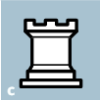

Cell 46


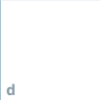

Cell 47


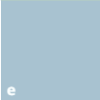

Cell 48


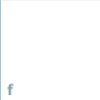

Cell 49


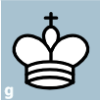

Total cells extracted: 49


In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# Sort lines
vertical_lines_sorted = sorted(vertical_lines, key=lambda x: x[0])
horizontal_lines_sorted = sorted(horizontal_lines, key=lambda x: x[1])

# Extract the x and y coordinates
xs = [x1 for (x1, y1, x2, y2) in vertical_lines_sorted]
ys = [y1 for (x1, y1, x2, y2) in horizontal_lines_sorted]

cells = []

counter = 1
for i in range(len(ys)-1):
    for j in range(len(xs)-1):
        y1, y2 = ys[i], ys[i+1]
        x1, x2 = xs[j], xs[j+1]

        cell = img[y1:y2, x1:x2]
        cells.append(cell)

        # Display each cell (optional – shows one by one)
        print(f"Cell {counter}")
        cv2_imshow(cell)
        counter += 1

print("Total cells extracted:", len(cells))

Detected board region:


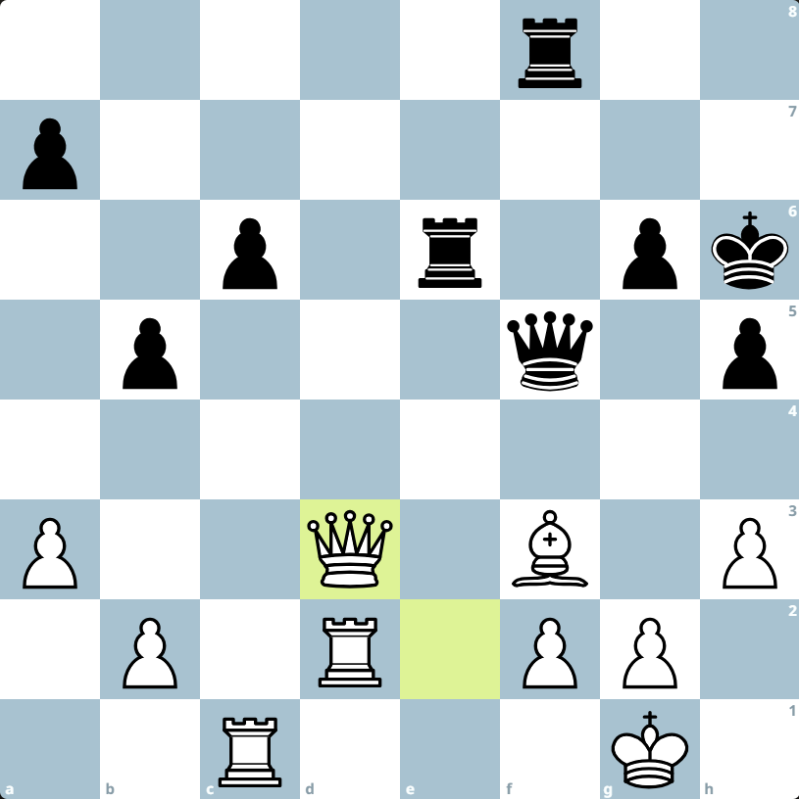

Cell 1


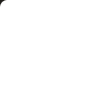

Cell 2


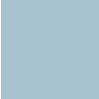

Cell 3


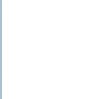

Cell 4


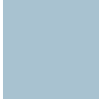

Cell 5


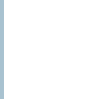

Cell 6


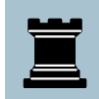

Cell 7


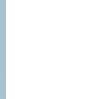

Cell 8


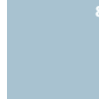

Cell 9


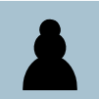

Cell 10


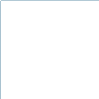

Cell 11


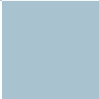

Cell 12


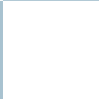

Cell 13


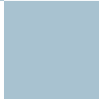

Cell 14


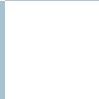

Cell 15


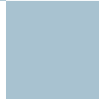

Cell 16


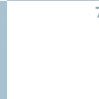

Cell 17


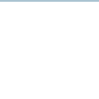

Cell 18


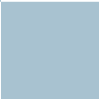

Cell 19


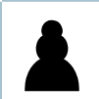

Cell 20


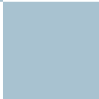

Cell 21


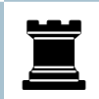

Cell 22


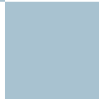

Cell 23


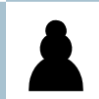

Cell 24


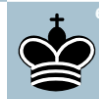

Cell 25


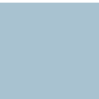

Cell 26


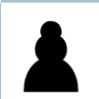

Cell 27


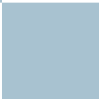

Cell 28


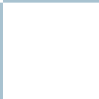

Cell 29


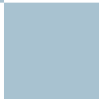

Cell 30


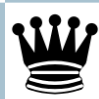

Cell 31


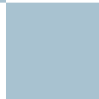

Cell 32


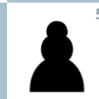

Cell 33


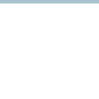

Cell 34


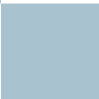

Cell 35


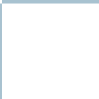

Cell 36


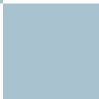

Cell 37


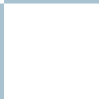

Cell 38


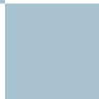

Cell 39


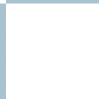

Cell 40


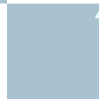

Cell 41


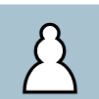

Cell 42


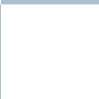

Cell 43


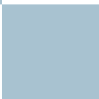

Cell 44


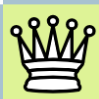

Cell 45


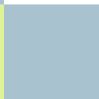

Cell 46


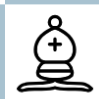

Cell 47


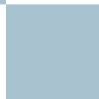

Cell 48


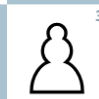

Cell 49


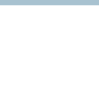

Cell 50


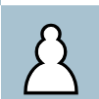

Cell 51


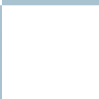

Cell 52


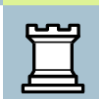

Cell 53


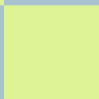

Cell 54


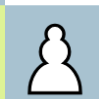

Cell 55


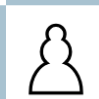

Cell 56


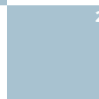

Cell 57


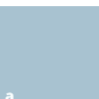

Cell 58


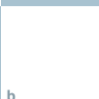

Cell 59


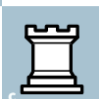

Cell 60


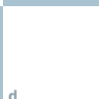

Cell 61


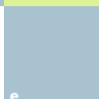

Cell 62


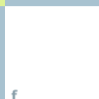

Cell 63


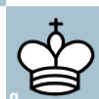

Cell 64


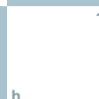

Total cells: 64


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

filename = "Screenshot 2025-12-06 143825.png"

# Load and resize
img = cv2.imread(filename)
img = cv2.resize(img, (800, int(img.shape[0] * 800 / img.shape[1])))

# Detect board region with color thresholding (Lichess blue squares)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Lichess light blue square range
lower = np.array([85, 20, 80])
upper = np.array([115, 80, 255])

mask = cv2.inRange(hsv, lower, upper)

# Get largest contour (which should be the chessboard)
cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest = max(cnts, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest)

board = img[y:y+h, x:x+w]

print("Detected board region:")
cv2_imshow(board)

# Now slice into 8x8
cell_w = w // 8
cell_h = h // 8

cells = []
counter = 1

for row in range(8):
    for col in range(8):
        y1 = row * cell_h
        y2 = (row+1) * cell_h
        x1 = col * cell_w
        x2 = (col+1) * cell_w

        cell = board[y1:y2, x1:x2]
        cells.append(cell)

        print(f"Cell {counter}")
        cv2_imshow(cell)
        counter += 1

print("Total cells:", len(cells))


In [ ]:
import os
import urllib.request
import cv2

# Create folder
os.makedirs("lichess_pieces", exist_ok=True)

# Template URLs (official Lichess alpha pieces)
templates = {
    "wP": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/wP.svg",
    "wR": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/wR.svg",
    "wN": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/wN.svg",
    "wB": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/wB.svg",
    "wQ": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/wQ.svg",
    "wK": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/wK.svg",
    "bP": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/bP.svg",
    "bR": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/bR.svg",
    "bN": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/bN.svg",
    "bB": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/bB.svg",
    "bQ": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/bQ.svg",
    "bK": "https://raw.githubusercontent.com/lichess-org/lila/master/public/piece/alpha/bK.svg",
}

# Download SVGs
for name, url in templates.items():
    out_path = f"lichess_pieces/{name}.svg"
    print("Downloading", name)
    urllib.request.urlretrieve(url, out_path)

In [ ]:
!pip install cairosvg

import os
import cairosvg

# Make sure output folder exists
os.makedirs("lichess_png", exist_ok=True)

png_templates = {}

print("Converting templates...")
for svg_file in os.listdir("lichess_pieces"):
    if svg_file.endswith(".svg"):
        name = svg_file[:-4]   # wP, bK, etc.
        svg_path = f"lichess_pieces/{svg_file}"
        png_path = f"lichess_png/{name}.png"

        # Convert SVG -> PNG
        cairosvg.svg2png(url=svg_path, write_to=png_path)

        png_templates[name] = png_path
        print("Converted:", name)

print("\nPNG templates loaded:")
print(png_templates)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 5.2 MB/s eta 0:00:00
Converting templates...
Converted: wN
Converted: bK
Converted: wB
Converted: bR
Converted: bB
Converted: bQ
Converted: wR
Converted: wK
Converted: bP
Converted: bN
Converted: wQ
Converted: wP

PNG templates loaded:
{'wN': 'lichess_png/wN.png', 'bK': 'lichess_png/bK.png', 'wB': 'lichess_png/wB.png', 'bR': 'lichess_png/bR.png', 'bB': 'lichess_png/bB.png', 'bQ': 'lichess_png/bQ.png', 'wR': 'lichess_png/wR.png', 'wK': 'lichess_png/wK.png', 'bP': 'lichess_png/bP.png', 'bN': 'lichess_png/bN.png', 'wQ': 'lichess_png/wQ.png', 'wP': 'lichess_png/wP.png'}


In [ ]:
import cv2
import numpy as np

# Load PNG templates (created earlier)
piece_templates = {}
for name, path in png_templates.items():
    tmpl = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if tmpl is None:
        print("Failed to load", path)
        continue

    # Handle RGBA → BGR → Gray
    if tmpl.shape[2] == 4:
        tmpl_rgb = cv2.cvtColor(tmpl, cv2.COLOR_BGRA2BGR)
    else:
        tmpl_rgb = tmpl
    tmpl_gray = cv2.cvtColor(tmpl_rgb, cv2.COLOR_BGR2GRAY)

    piece_templates[name] = tmpl_gray

print("Loaded templates:", list(piece_templates.keys()))

# Map Lichess codes → FEN characters
fen_map = {
    "wP": "P", "wN": "N", "wB": "B", "wR": "R", "wQ": "Q", "wK": "K",
    "bP": "p", "bN": "n", "bB": "b", "bR": "r", "bQ": "q", "bK": "k"
}

def detect_piece(cell_img, threshold=0.45):
    """Return (FEN_char or None, score) for a given board cell."""
    cell_gray = cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY)
    ch, cw = cell_gray.shape[:2]

    best_piece = None
    best_score = -1.0

    for code, tmpl in piece_templates.items():
        th, tw = tmpl.shape[:2]

        # Scale template to cell size
        scale = min(ch / th, cw / tw)
        if scale <= 0:
            continue

        new_size = (int(tw * scale), int(th * scale))
        tmpl_resized = cv2.resize(tmpl, new_size)

        res = cv2.matchTemplate(cell_gray, tmpl_resized, cv2.TM_CCOEFF_NORMED)
        score = res.max()

        if score > best_score:
            best_score = score
            best_piece = code

    if best_score < threshold:
        return None, best_score  # empty square

    return fen_map[best_piece], best_score

# Test detection on all 64 cells
board_pieces = []
for idx, cell in enumerate(cells):
    piece, score = detect_piece(cell)
    board_pieces.append(piece if piece is not None else ".")
    print(f"Cell {idx+1}: {piece} (score={score:.2f})")

print("\nTotal pieces detected (non-empty):",
      sum(1 for p in board_pieces if p != "."))


Loaded templates: ['wN', 'bK', 'wB', 'bR', 'bB', 'bQ', 'wR', 'wK', 'bP', 'bN', 'wQ', 'wP']
Cell 1: None (score=0.02)
Cell 2: None (score=-0.03)
Cell 3: None (score=0.09)
Cell 4: None (score=-0.05)
Cell 5: None (score=0.13)
Cell 6: None (score=-0.18)
Cell 7: None (score=0.17)
Cell 8: None (score=-0.08)
Cell 9: None (score=-0.09)
Cell 10: None (score=0.09)
Cell 11: None (score=-0.05)
Cell 12: None (score=0.13)
Cell 13: None (score=-0.07)
Cell 14: None (score=0.16)
Cell 15: None (score=-0.08)
Cell 16: None (score=0.19)
Cell 17: None (score=0.09)
Cell 18: None (score=-0.05)
Cell 19: None (score=-0.11)
Cell 20: None (score=-0.06)
Cell 21: None (score=-0.17)
Cell 22: None (score=-0.08)
Cell 23: None (score=-0.13)
Cell 24: None (score=-0.18)
Cell 25: None (score=-0.05)
Cell 26: None (score=-0.08)
Cell 27: None (score=-0.06)
Cell 28: None (score=0.16)
Cell 29: None (score=-0.08)
Cell 30: None (score=-0.17)
Cell 31: None (score=-0.09)
Cell 32: None (score=-0.12)
Cell 33: None (score=0.13)
Cell 

In [ ]:
import cv2
import numpy as np

X_cells = []

for idx, cell in enumerate(cells):
    resized = cv2.resize(cell, (64, 64))
    X_cells.append(resized)

X_cells = np.array(X_cells)

print("Prepared cells for CNN:", X_cells.shape)   # (64, 64, 64, 3)


Prepared cells for CNN: (64, 64, 64, 3)


In [ ]:
import chess

fen = "4r3/p7/1p1r1pk1/p4qp1/8/p2q1bp1/1p1rp1pp/2r4k"

board = chess.Board(fen)

label_map = {
    None: ".",
    chess.Piece.from_symbol('P'): "P",
    chess.Piece.from_symbol('N'): "N",
    chess.Piece.from_symbol('B'): "B",
    chess.Piece.from_symbol('R'): "R",
    chess.Piece.from_symbol('Q'): "Q",
    chess.Piece.from_symbol('K'): "K",
    chess.Piece.from_symbol('p'): "p",
    chess.Piece.from_symbol('n'): "n",
    chess.Piece.from_symbol('b'): "b",
    chess.Piece.from_symbol('r'): "r",
    chess.Piece.from_symbol('q'): "q",
    chess.Piece.from_symbol('k'): "k",
}

y_labels = []
for square in chess.SQUARES_180:   # top-left (a8) → bottom-right (h1)
    piece = board.piece_at(square)
    y_labels.append(label_map[piece])

print("Total labels:", len(y_labels))
print(y_labels)


Total labels: 64
['.', '.', '.', '.', 'r', '.', '.', '.', 'p', '.', '.', '.', '.', '.', '.', '.', '.', 'p', '.', 'r', '.', 'p', 'k', '.', 'p', '.', '.', '.', '.', 'q', 'p', '.', '.', '.', '.', '.', '.', '.', '.', '.', 'p', '.', '.', 'q', '.', 'b', 'p', '.', '.', 'p', '.', 'r', 'p', '.', 'p', 'p', '.', '.', 'r', '.', '.', '.', '.', 'k']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# Convert labels to class indices
classes = sorted(list(set(y_labels)))  # ['.', 'b', 'k', 'p', 'q', 'r']
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

y_idx = np.array([class_to_idx[c] for c in y_labels])

# Prepare X_cells (64x64x3)
X = X_cells.astype("float32") / 255.0
y = y_idx

# Data augmentation
data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

# Build CNN model
model = models.Sequential([
    layers.Input(shape=(64,64,3)),
    data_augment,
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("Training CNN...")
history = model.fit(X, y, epochs=20, batch_size=16, verbose=1)

print("Training complete.")


Training CNN...
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.4313 - loss: 1.5788
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7542 - loss: 0.9840
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7083 - loss: 1.0110
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7688 - loss: 0.9007
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.6938 - loss: 1.0032
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6854 - loss: 0.9421
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6875 - loss: 0.9464
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7083 - loss: 0.8908
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7354 - loss: 0.7774
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7854 - loss: 0.7071
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6812 - loss: 0.9440
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6938

In [ ]:
import numpy as np

print("Predicting pieces on the 64 cells...")

preds = model.predict(X)

pred_classes = [idx_to_class[np.argmax(p)] for p in preds]

print("\nPredicted piece classes:")
print(pred_classes)

# Show how many non-empty squares the model recognized
non_empty = sum(1 for p in pred_classes if p != ".")
print("\nDetected non-empty squares:", non_empty)


Predicting pieces on the 64 cells...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step 

Predicted piece classes:
['.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', 'q', '.', '.', '.', '.', '.', 'q', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', 'p', '.', '.', 'q', '.', 'r', '.', 'p', '.', 'p', '.', 'r', '.', 'p', 'p', '.', '.', '.', 'r', '.', '.', '.', '.', '.']

Detected non-empty squares: 11


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.35),
    layers.RandomZoom(0.25),
    layers.RandomContrast(0.4),
    layers.RandomBrightness(factor=0.3),
])

print("Generating augmented dataset...")

X_aug = []
y_aug = []

for i in range(len(X)):
    for _ in range(150):      # 150 augmentations per cell
        img = tf.expand_dims(X[i], axis=0)
        out = aug(img)
        X_aug.append(out.numpy()[0])
        y_aug.append(y[i])

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("Augmented dataset ready.")
print("X_aug shape:", X_aug.shape)
print("y_aug shape:", y_aug.shape)


Generating augmented dataset...
Augmented dataset ready.
X_aug shape: (9600, 64, 64, 3)
y_aug shape: (9600,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Training improved CNN...")

model2 = models.Sequential([
    layers.Input(shape=(64,64,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

model2.compile(optimizer="adam",
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])

history = model2.fit(X_aug, y_aug, epochs=10, batch_size=64, verbose=1)

print("Training complete.")


Training improved CNN...
Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 57s 368ms/step - accuracy: 0.6608 - loss: 1.5269
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 79s 350ms/step - accuracy: 0.6792 - loss: 1.0475
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 352ms/step - accuracy: 0.6837 - loss: 1.0327
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 83s 358ms/step - accuracy: 0.6886 - loss: 1.0151
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 361ms/step - accuracy: 0.6814 - loss: 1.0273
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 82s 359ms/step - accuracy: 0.6904 - loss: 1.0133
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 82s 360ms/step - accuracy: 0.6932 - loss: 0.9981
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 83s 366ms/step - accuracy: 0.6887 - loss: 1.0214
Epoch 9/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 361ms/step - accuracy: 0.6869 - loss: 1.0180
Epoch 10/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 360ms/step - accuracy: 0.6808 - loss: 1.0356
Training complete.


In [ ]:
import cv2
import numpy as np

# ORB detector
orb = cv2.ORB_create(500)

# Load template descriptors
template_kp = {}
template_desc = {}

for name, path in png_templates.items():
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    kp, desc = orb.detectAndCompute(img, None)
    template_kp[name] = kp
    template_desc[name] = desc

print("ORB templates ready.")


ORB templates ready.


In [ ]:
import cv2
import numpy as np

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

def detect_piece_orb(cell_img):
    cell_gray = cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY)
    kp2, desc2 = orb.detectAndCompute(cell_gray, None)

    if desc2 is None:
        return ".", 0  # empty or no features

    best_piece = "."
    best_matches = 0

    for name, desc1 in template_desc.items():
        if desc1 is None:
            continue

        matches = bf.match(desc1, desc2)
        matches = sorted(matches, key=lambda x: x.distance)

        # Number of good matches (lower distance = better)
        good = sum(1 for m in matches if m.distance < 40)

        if good > best_matches:
            best_matches = good
            best_piece = name

    # Threshold: if too few matches → empty square
    if best_matches < 5:
        return ".", best_matches

    return best_piece, best_matches


print("Detecting pieces on your board using ORB...")

pred_pieces = []
match_scores = []

for idx, cell in enumerate(cells):
    p, score = detect_piece_orb(cell)
    pred_pieces.append(p)
    match_scores.append(score)
    print(f"Cell {idx+1}: {p}   (matches={score})")

non_empty = sum(1 for p in pred_pieces if p != ".")
print("\nDetected non-empty squares:", non_empty)

pred_pieces


Detecting pieces on your board using ORB...
Cell 1: .   (matches=0)
Cell 2: .   (matches=0)
Cell 3: .   (matches=0)
Cell 4: .   (matches=0)
Cell 5: .   (matches=0)
Cell 6: .   (matches=0)
Cell 7: .   (matches=0)
Cell 8: .   (matches=0)
Cell 9: wN   (matches=6)
Cell 10: .   (matches=0)
Cell 11: .   (matches=0)
Cell 12: .   (matches=0)
Cell 13: .   (matches=0)
Cell 14: .   (matches=0)
Cell 15: .   (matches=0)
Cell 16: .   (matches=0)
Cell 17: .   (matches=0)
Cell 18: .   (matches=0)
Cell 19: wN   (matches=6)
Cell 20: .   (matches=0)
Cell 21: .   (matches=0)
Cell 22: .   (matches=0)
Cell 23: wN   (matches=6)
Cell 24: .   (matches=0)
Cell 25: .   (matches=0)
Cell 26: wB   (matches=6)
Cell 27: .   (matches=0)
Cell 28: .   (matches=0)
Cell 29: .   (matches=0)
Cell 30: .   (matches=0)
Cell 31: .   (matches=0)
Cell 32: wB   (matches=5)
Cell 33: .   (matches=0)
Cell 34: .   (matches=0)
Cell 35: .   (matches=0)
Cell 36: .   (matches=0)
Cell 37: .   (matches=0)
Cell 38: .   (matches=0)
Cell 39: .

['.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 'wN',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 'wN',
 '.',
 '.',
 '.',
 'wN',
 '.',
 '.',
 'wB',
 '.',
 '.',
 '.',
 '.',
 '.',
 'wB',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.',
 '.']